In [71]:
from __future__ import annotations
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.cross_decomposition import CCA

###############################################################################
# Paths & constants
###############################################################################
PUPIL_ROOT = Path(r"C:\Users\cdd\Documents\Uni\Special_course\pupil_processed_clara")
EEG_ROOT   = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\eeg_theta_processed2")

FRONTAL_MIDLINE = ['AFz','AF3','AF4','Fz','F1','F2','F3','F4','FC3','FC1','FC2','FC4','Cz','C3','C1','C2','C4']

OUT_TRIALS  = Path("trial_level_cca_fixedlag.csv")
OUT_SUBJECT = Path("subject_best_lag.csv")

SUBJECTS = np.setdiff1d(np.arange(32, 43), [32, 37, 53, 61, 66, 78, 84, 90, 94, 96])
#SUBJECTS = np.setdiff1d(np.arange(32, 99), [32, 37, 53, 61, 66, 78, 84, 90, 94, 96])
SHIFTS = np.arange(-100, 101)      # ±1 s at 100 Hz → samples
WIN_OFFSET1 = 200                  # discard first 200 ms
WIN_OFFSET2 = 110                  # discard last 110 ms

###############################################################################
# Helper functions
###############################################################################

def normalise_eeg(x: np.ndarray) -> np.ndarray:
    """Centre each channel and scale so Σ x² = 1 over time×channels."""
    x = x - x.mean(axis=0, keepdims=True)
    scale = np.sqrt(np.mean(x**2))
    return x / scale


def cca_corr(eeg: np.ndarray, pupil: np.ndarray) -> float:
    """Canonical correlation (single component)."""
    cca = CCA(n_components=1, max_iter=1000, scale=False, tol=1e-6)
    cca.fit(eeg, pupil)
    u, v = cca.transform(eeg, pupil)
    return float(np.corrcoef(u[:, 0], v[:, 0])[0, 1])


In [67]:
def load_all_trials(
        sub: int,
        eeg_root: Path = EEG_ROOT,
        pupil_root: Path = PUPIL_ROOT,
        min_len: int = 40,
        max_len_diff: int = 30,
) -> list[tuple[np.ndarray, np.ndarray, dict]]:
    """
    Load *all* valid EEG-pupil trial pairs for one subject.

    Parameters
    ----------
    sub : int
        Numeric subject ID (e.g. 42).
    eeg_root, pupil_root : Path
        Roots of the pre-processed EEG and pupil folders.
    min_len : int
        Minimum number of samples a pupil trace must have to be accepted.
    max_len_diff : int
        Reject trial if |len(pupil)-len(eeg)| exceeds this.
    Returns
    -------
    trials : list of (eeg, pupil_z, meta)
        * eeg        – (T × n_channels) float64, already centred/scaled
        * pupil_z    – (T × 1) float64, per-trial z-scored
        * meta       – dict with subject/condition/load/epoch
    """
    trials = []
    sub_tag = f"sub-{sub:03d}"
    eeg_sub  = eeg_root   / sub_tag
    pupil_sub = pupil_root / sub_tag

    if not eeg_sub.exists():
        print(f"{sub_tag}: EEG folder missing - skipped")
        return trials

    # iterate condition (“control” / “memory”) and load (“05” / “09” / “13”)
    for cond_path in sorted(eeg_sub.iterdir()):
        if not cond_path.is_dir():
            continue
        for load_path in sorted(cond_path.iterdir()):
            if not load_path.is_dir():
                continue

            # matching pupil directory
            pupil_path = pupil_sub / cond_path.name / load_path.name
            if not pupil_path.exists():
                continue

            eeg_epochs   = sorted(load_path.glob("trial_*.csv"))
            pupil_epochs = sorted(pupil_path.glob("trial_*.csv"))
            common = {f.name for f in eeg_epochs} & {f.name for f in pupil_epochs}
            if not common:
                continue

            for fname in sorted(common):
                eeg_df = pd.read_csv(load_path / fname, comment="#", index_col=0)
                pupil_df = pd.read_csv(pupil_path / fname, comment="#",
                                       names=["time", "diameter_z"], index_col=0)

                eeg   = eeg_df.values.astype(float)
                pupil = pupil_df["diameter_z"].values.astype(float)

                # basic validity checks
                if len(pupil) < min_len or abs(len(pupil) - len(eeg)) > max_len_diff:
                    continue

                # normalise signals ----------------------------------------
                eeg_norm = normalise_eeg(eeg)           # your helper from before
                pupil_z  = ((pupil - pupil.mean()) / pupil.std(ddof=0))

                # same number of samples
                T = min(len(eeg_norm), len(pupil_z))
                eeg_norm = eeg_norm[0:T, :]  # (T × n_channels)
                pupil_z  = pupil_z[0:T].reshape(-1, 1)

                meta = {
                    "subject":   sub_tag,
                    "condition": cond_path.name,
                    "load":      int(load_path.name),
                    "epoch":     fname
                }
                trials.append((eeg_norm, pupil_z, meta))

    return trials

from typing import List, Tuple
import numpy as np

def split_trials_by_condition(
        trials: List[Tuple[np.ndarray, np.ndarray, dict]],
        memory_label: str = "memory",
        control_label: str = "control"
) -> Tuple[List[Tuple[np.ndarray, np.ndarray, dict]], List[Tuple[np.ndarray, np.ndarray, dict]]]:
    """
    Separate a mixed list of (eeg, pupil, meta) trial tuples into memory-condition and control-condition sub-lists.

    Parameters
    ----------
    trials : list of tuples
        Each tuple = (eeg_array, pupil_array, meta_dict).
        meta_dict must contain a key 'condition'.
    memory_label : str
        The value of meta['condition'] that marks a memory trial.
    control_label : str
        The value of meta['condition'] that marks a control trial.

    Returns
    -------
    memory_trials  : list[tuple]
    control_trials : list[tuple]
    """
    memory_trials  = []
    control_trials = []

    for eeg, pupil, meta in trials:
        cond = meta.get("condition", "").lower()
        if cond == memory_label:
            memory_trials.append((eeg, pupil, meta))
        elif cond == control_label:
            control_trials.append((eeg, pupil, meta))
        else: raise ValueError(f"Unknown condition label: {cond}")

    return memory_trials, control_trials


In [68]:
import numpy as np
from typing import List, Tuple, Dict

def search_best_lag(
        train_trials: List[Tuple[np.ndarray, np.ndarray, dict]],
        shifts: np.ndarray = SHIFTS,
        return_curve: bool = False
) -> Tuple[float, int, Dict[int, float] | None]:
    """
    Search for the lag (sample shift) that maximises the mean canonical
    correlation between EEG and pupil traces in a training set.

    Parameters
    ----------
    train_trials : list of (eeg, pupil_z, meta)
        Each eeg  : 2-D array [time × channels or CCA-components]
        Each pupil: 1-D array [time]
    shifts : np.ndarray
        Array of integer lag shifts (positive = EEG is moved forward).
    return_curve : bool, default False
        If True, also return the full {shift: mean_r} dictionary.

    Returns
    -------
    best_corr : float
        Highest mean canonical correlation found.
    best_shift : int
        Shift (samples) that maximised the correlation.
    mean_r_per_shift : dict | None
        Only when `return_curve` is True.
    """
    win = slice(WIN_OFFSET1, -WIN_OFFSET2)         # common window
    mean_r_per_shift: Dict[int, float] = {}

    for s in shifts:                               # <-- loop over *shifts*, not SHIFTS
        rs = []
        for eeg, pupil_z, _ in train_trials:
            eeg_shifted = np.roll(eeg, s, axis=0)[win]
            r = cca_corr(eeg_shifted, pupil_z[win])
            rs.append(r)
        mean_r_per_shift[s] = float(np.mean(rs))   # cast to plain float for JSON-ability

    best_shift = max(mean_r_per_shift, key=mean_r_per_shift.get)
    best_corr  = mean_r_per_shift[best_shift]

    if return_curve:
        return best_corr, best_shift, mean_r_per_shift
    else:
        return best_corr, best_shift, None


In [69]:

from typing import List, Tuple, Optional

# trials  : list of (eeg, pupil_z, meta)   –– the tuples returned by load_all_trials
# shift   : integer sample shift (best_shift)
# win     : slice or None                  –– cropping window (set to None if the
#                                            trials are already pre-trimmed)
def concat_trials(
        trials: List[Tuple[np.ndarray, np.ndarray, dict]],
        shift: int = 0,
        win: Optional[slice] = None
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Concatenate a list of trials into one long matrix pair ready for CCA.

    Returns
    -------
    X  : ndarray, shape (Σ Tᵢ, n_channels)
    Y  : ndarray, shape (Σ Tᵢ, 1)
    """
    X_blocks, Y_blocks = [], []

    for eeg, pupil_z, _ in trials:
        # 1. roll *inside* the trial so samples never cross trial boundaries
        eeg_shift = np.roll(eeg, shift, axis=0)

        # 2. optional windowing (do it once here if you did **not** crop in loader)
        if win is not None:
            eeg_shift = eeg_shift[win]
            pupil_seg = pupil_z[win]
        else:
            pupil_seg = pupil_z          # already trimmed earlier

        # 3. stack
        X_blocks.append(eeg_shift)
        Y_blocks.append(pupil_seg)

    X = np.vstack(X_blocks)
    Y = np.vstack(Y_blocks)
    return X, Y

def iterate_trials(trials, shift, win):
    """Yield (eeg_shifted, pupil_z_windowed, meta) one by one."""
    for eeg, pupil_z, meta in trials:
        eeg_s = np.roll(eeg, shift, axis=0)[win]
        yield eeg_s, pupil_z[win], meta.copy()

import pandas as pd
import json
from pathlib import Path

def save_cca_weights(cca, subject_tag, lag_ms, eeg_ch_names, condition, out_dir=Path("weights")):
    """
    Dump EEG & pupil canonical weights to CSV/JSON for one subject.

    Parameters
    ----------
    cca            : fitted sklearn.cross_decomposition.CCA
    subject_tag    : "sub-042"
    lag_ms         : e.g. -90
    eeg_ch_names   : list[str] same order as columns in your trial matrices
    out_dir        : destination folder (created if missing)
    """
    out_dir.mkdir(parents=True, exist_ok=True)

    # ------- Pupil weight -> JSON ---------------------------------------
    w_pupil = float(cca.y_weights_[0, 0])   # scalar in 1-dim pupil case
    w_pupil = w_pupil / w_pupil
    with open(out_dir / f"{subject_tag}_pupil_weight_{condition}_{lag_ms:+d}ms.json", "w") as fh:
        json.dump({"weight": w_pupil}, fh, indent=2)
    
    # ------- EEG weights -> tidy CSV ------------------------------------
    w_eeg = cca.x_weights_[:, 0] / w_pupil
    w_eeg = pd.Series(w_eeg, index=eeg_ch_names, name="weight")
    w_eeg.index.name = "channel"
    w_eeg.to_csv(out_dir / f"{subject_tag}_eeg_weights_{condition}_{lag_ms:+d}ms.csv")

    print(f"saved weights for {subject_tag} (lag {lag_ms:+d} ms)")



Subject 33: best lag -50 ms with r = 0.480


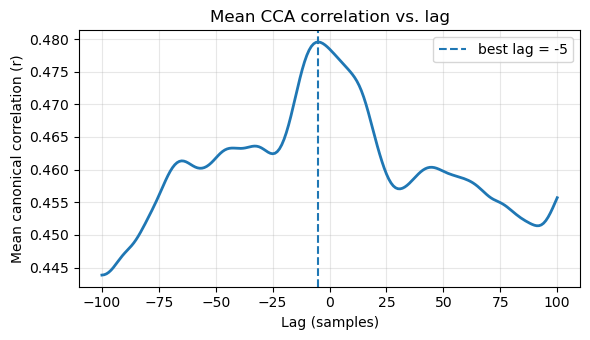

saved weights for sub-033 (lag -50 ms)
saved weights for sub-033 (lag -50 ms)
Subject 34: best lag 320 ms with r = 0.470


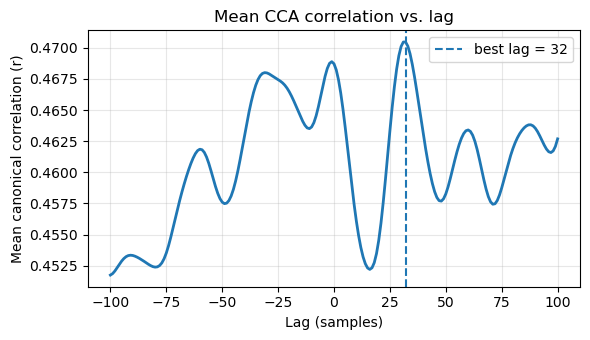

saved weights for sub-034 (lag +320 ms)
saved weights for sub-034 (lag +320 ms)
Subject 35: best lag -80 ms with r = 0.542


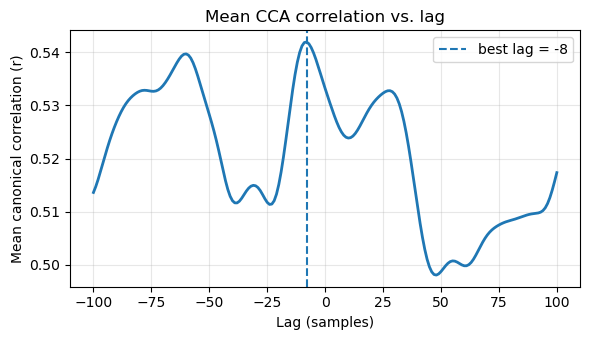

saved weights for sub-035 (lag -80 ms)
saved weights for sub-035 (lag -80 ms)
Subject 36: best lag -590 ms with r = 0.492


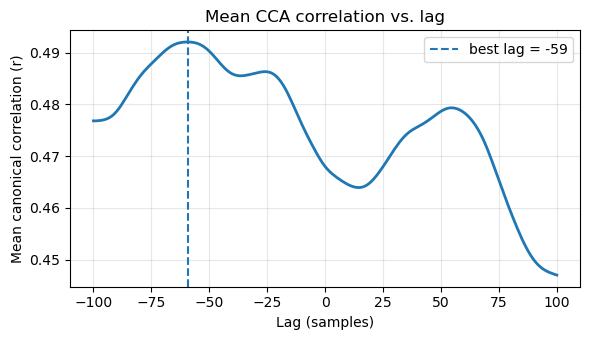

saved weights for sub-036 (lag -590 ms)
saved weights for sub-036 (lag -590 ms)
Subject 38: best lag -10 ms with r = 0.488


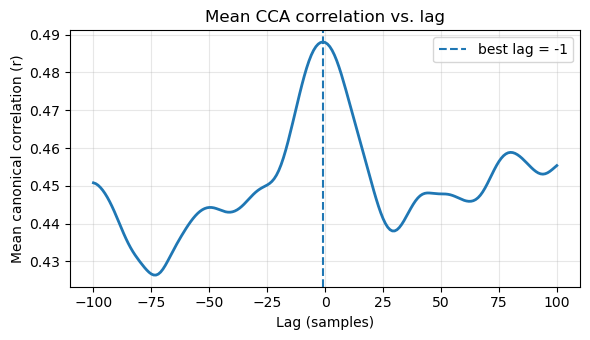

saved weights for sub-038 (lag -10 ms)
saved weights for sub-038 (lag -10 ms)
Subject 39: best lag 20 ms with r = 0.501


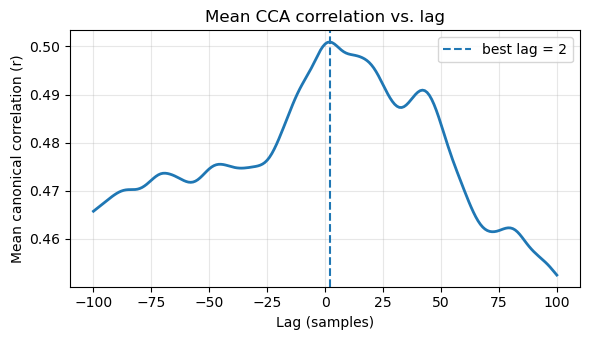

saved weights for sub-039 (lag +20 ms)
saved weights for sub-039 (lag +20 ms)
Subject 40: best lag 1000 ms with r = 0.512


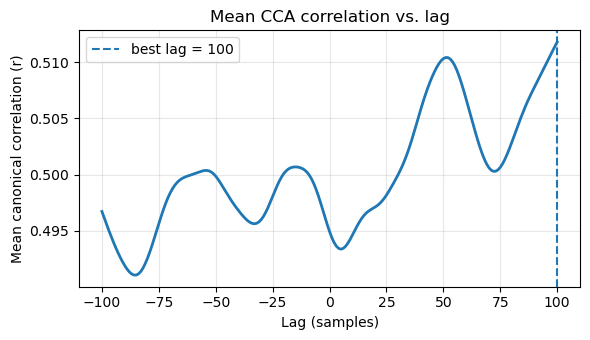

saved weights for sub-040 (lag +1000 ms)
saved weights for sub-040 (lag +1000 ms)
Subject 41: best lag -100 ms with r = 0.477


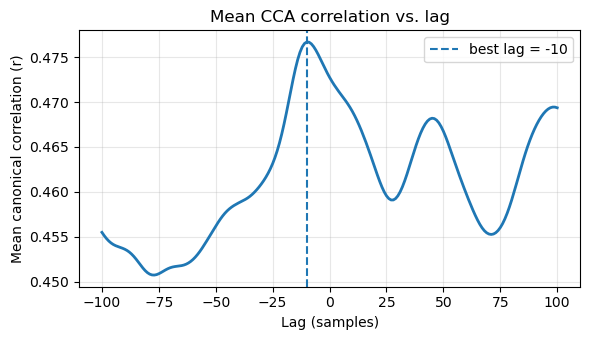

saved weights for sub-041 (lag -100 ms)
saved weights for sub-041 (lag -100 ms)
Subject 42: best lag -800 ms with r = 0.496


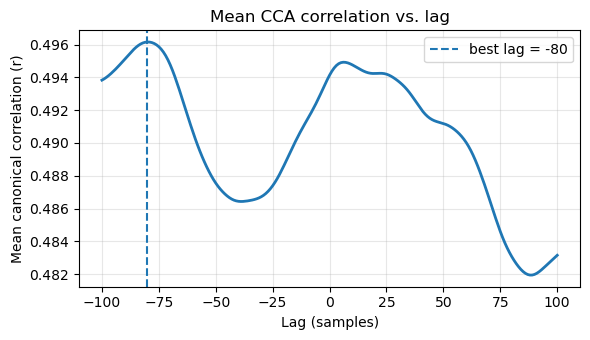

saved weights for sub-042 (lag -800 ms)
saved weights for sub-042 (lag -800 ms)
Finished - saved per-trial correlations with plain CCA.


In [72]:
all_rows = []  # collect all trial-level results here

for subj in SUBJECTS:
    trials = load_all_trials(subj)                         # list of (eeg, pupil)
    trials_memory, trials_control = split_trials_by_condition(trials)
    
    # ----- lag search on memory ------------------------------------------
    best_corr, best_shift, mean_r_per_shift = search_best_lag(trials_memory, SHIFTS, return_curve = True)
    print(f"Subject {subj:02d}: best lag {best_shift*10} ms with r = {best_corr:.3f}")
    
    # -------------------------------------------------------------
    # 2) Build x and y vectors for plotting
    # -------------------------------------------------------------
    lags   = np.array(sorted(mean_r_per_shift))                 # x-axis (samples)
    r_mean = np.array([mean_r_per_shift[s] for s in lags])      # y-axis (mean r)

    # If you prefer milliseconds instead of samples:
    # fs = 1000  # replace with your real sampling rate
    # lags = lags * 1000 / fs

    # -------------------------------------------------------------
    # 3) Plot
    # -------------------------------------------------------------
    import matplotlib.pyplot as plt

    plt.figure(figsize=(6, 3.5))
    plt.plot(lags, r_mean, lw=2)
    plt.axvline(best_shift, ls='--', lw=1.5,
                label=f'best lag = {best_shift}')
    plt.xlabel('Lag (samples)')
    plt.ylabel('Mean canonical correlation (r)')
    plt.title('Mean CCA correlation vs. lag')
    plt.grid(alpha=.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    # ----- fit weights ONCE using all train trials at best_shift ---------
    win = slice(WIN_OFFSET1, -WIN_OFFSET2)
    

    X_mem, Y_mem = concat_trials(trials_memory, shift=best_shift, win=win)
    X_ctrl, Y_ctrl = concat_trials(trials_control, shift=best_shift, win=win)
    
    cca_mem = CCA(n_components=1, max_iter=1000, scale=False, tol=1e-6)
    cca_mem.fit(X_mem, Y_mem)
    
    cca_ctrl = CCA(n_components=1, max_iter=1000, scale=False, tol=1e-6)
    cca_ctrl.fit(X_ctrl, Y_ctrl)
    
    save_cca_weights(cca_mem, subject_tag=f"sub-{subj:03d}", lag_ms=best_shift*10, condition = "mem", eeg_ch_names=FRONTAL_MIDLINE)
    save_cca_weights(cca_ctrl, subject_tag=f"sub-{subj:03d}", lag_ms=best_shift*10, condition = "ctrl", eeg_ch_names=FRONTAL_MIDLINE)

    # ----- per-trial r on TEST with frozen lag & weights -----------------
    for eeg_s, pupil_s, meta in iterate_trials(trials_memory, best_shift, win):
        u, v = cca_mem.transform(eeg_s, pupil_s)
        meta['r'] = float(np.corrcoef(u[:, 0], v[:, 0])[0,1])
        meta['lag_ms'] = best_shift *10
        all_rows.append(meta)
    for eeg_s, pupil_s, meta in iterate_trials(trials_control, best_shift, win):
        u, v = cca_ctrl.transform(eeg_s, pupil_s)
        meta['r'] = float(np.corrcoef(u[:, 0], v[:, 0])[0,1])
        meta['lag_ms'] = best_shift *10
        all_rows.append(meta)
    # (optional) swap train/test and repeat so every trial gets a score

##############################################################################
# ---- save -----------------------------------------------------------------
##############################################################################
pd.DataFrame(all_rows).to_csv("trial_level_cca_fixedlag_splitCV3.csv", index=False)
print("Finished - saved per-trial correlations with plain CCA.")


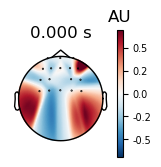

In [20]:
# ---------------------------------------------------------------
#  Topomap from CSV  (MNE ≥ 1.0)   •   Author: ChatGPT
# ---------------------------------------------------------------
import pandas as pd
import numpy as np
import mne
import matplotlib.pyplot as plt
from pathlib import Path
from packaging import version        # for backward-compatible vlim/vmin,vmax

# ------------ 1.  load the CSV  --------------------------------
csv_path = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\weights\sub-039_eeg_weights_ctrl_+20ms.csv")
df = pd.read_csv(csv_path)           # expects columns 'channel' and 'weight'

# ------------ 2.  build an MNE EvokedArray  --------------------
ch_names = df['channel'].tolist()
weights  = df['weight'].to_numpy()

info = mne.create_info(ch_names, sfreq=1000, ch_types='eeg')
info.set_montage(mne.channels.make_standard_montage('standard_1020'))

# reshape to (n_channels, n_times) with one “time sample”
evoked = mne.EvokedArray(weights.reshape(len(ch_names), 1), info, tmin=0)

# ------------ 3.  plot the topomap  ----------------------------
vmax = np.abs(weights).max()        # symmetric colour-limits

plot_args = dict(
    times=[0],                      # list for MNE ≥ 1.0
    scalings=1,
    cmap='RdBu_r',
    contours=0,
    sensors=True,
    sphere=0.09
)

plot_args['vlim'] = (-vmax, vmax)

fig = evoked.plot_topomap(**plot_args)
plt.show()


In [64]:
# 1. ------------- imports & data ------------------------------------------
import pandas as pd
import numpy as np
from scipy import stats

DF = pd.read_csv("trial_level_cca_fixedlag_splitCV3.csv")
DF["r"] = DF["r"].abs()  # use absolute values for the test

# 2. ------------- collapse to subject-level means --------------------------
sub_means = (DF
             .groupby(["subject", "condition"])["r"]
             .mean()
             .unstack("condition")           # columns: control, memory
             .dropna())                      # keep subjects that have both

control  = sub_means["control"].values
memory   = sub_means["memory"].values
delta    = memory - control                 # positive = memory > control

print(f"N subjects = {len(delta)}")
print(f"Mean Δr     = {delta.mean():.4f}")

# 3. ------------- paired t-test -------------------------------------------
t_stat, p_t = stats.ttest_rel(memory, control, alternative="greater")
print(f"Paired t-test:  t = {t_stat:.3f},  one-sided p = {p_t:.4f}")

# 4. ------------- permutation test (10 000 label flips) --------------------
rng = np.random.default_rng(42)
n_perm = 10_000
perm_stats = []

for _ in range(n_perm):
    signs = rng.choice([1, -1], size=len(delta))   # random swap of cond labels
    perm_stats.append((signs * delta).mean())

perm_stats = np.array(perm_stats)
p_perm = (np.sum(perm_stats >= delta.mean()) + 1) / (n_perm + 1)   # add-1 rule

print(f"Permutation test:  one-sided p = {p_perm:.4f}")


N subjects = 6
Mean Δr     = -0.0293
Paired t-test:  t = -2.184,  one-sided p = 0.9596
Permutation test:  one-sided p = 0.9562


In [63]:
from pathlib import Path
import re, pandas as pd, numpy as np
from scipy import stats
import matplotlib.pyplot as plt

WEIGHT_DIR = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\weights")

CORE_THETA = ["AFz", "Fz", "Cz"]      # 5-channel ROI

pattern = re.compile(r"(sub-\d{3})_eeg_weights_(mem|ctrl)_[+-]?\d+ms\.csv")
records = []

for csv_file in WEIGHT_DIR.glob("sub-*_eeg_weights_*ms.csv"):
    m = pattern.match(csv_file.name)
    if not m:
        continue
    subj, cond = m.groups()                         # "sub-033", "mem"/"ctrl"
    df = pd.read_csv(csv_file, index_col="channel") # channel,weight

    # quick sanity: require the 5 ROI channels
    if not set(CORE_THETA).issubset(df.index):
        print(f"{csv_file.name}: missing ROI channels – skipped")
        continue

    roi_mean = df.loc[CORE_THETA, "weight"].abs().mean()   # |weight| → strength
    records.append({"subject": subj, "condition": cond, "roi_mean": roi_mean})

# ---------- tidy subject-level table ---------------------------------------
tbl = (pd.DataFrame(records)
         .pivot(index="subject", columns="condition", values="roi_mean")
         .dropna())                     # keep subjects that have both conds
tbl["delta"] = tbl["mem"] - tbl["ctrl"]

print("\n=== Mean |weight| on core Fm-θ channels ===")
print(tbl.round(4))

# ---------- paired t-test & Wilcoxon ---------------------------------------
t, p_t = stats.ttest_rel(tbl["mem"], tbl["ctrl"], alternative="greater")
w, p_w = stats.wilcoxon(tbl["mem"], tbl["ctrl"], alternative="greater")

print(f"\nPaired t-test    : t = {t:.3f}, one-sided p = {p_t:.4f}")
print(f"Wilcoxon signed-r: W = {w:.0f}, one-sided p = {p_w:.4f}")
print(f"Mean Δ|weight|   : {tbl['delta'].mean():.4f}")

# ---------- paired dot plot -------------------------------------------------
fig, ax = plt.subplots(figsize=(4,4))
x = np.arange(len(tbl))
ax.scatter(x-0.05, tbl["ctrl"],  marker="o", label="control", color="steelblue")
ax.scatter(x+0.05, tbl["mem"],   marker="^", label="memory",  color="darkorange")
for i, (c, m) in enumerate(zip(tbl["ctrl"], tbl["mem"])):
    ax.plot([i-0.05, i+0.05], [c, m], color='gray', alpha=.5)
ax.set_xticks(x)
ax.set_xticklabels(tbl.index, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("mean |weight| (AFz, Fz, FC1, FC2, Cz)")
ax.set_title("Frontal-midline θ weights\nmemory vs. control")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


ValueError: Index contains duplicate entries, cannot reshape